# CompileML on the insurance fraud cold-start set

A guided walk through [compileml](https://github.com/orgoca/CompileML) 0.4.3, the package you are testing
for its author. Same data and same teacher as `scripts/01_insurance_fraud_end_to_end.py`, but with the
reasoning between the steps and the intermediate objects inspected.

The claim under test: *train the strongest teacher you like, distill it into a shallow integer whitebox,
and ship one hashed JSON that scores, bands, calibrates and explains itself with only the standard library.*

Sections

1. Data and teacher
2. Distillation: `train_whitebox` and what fidelity means
3. Bands: why quantile edges collide here, and what the certified builders say
4. The artifact: what is in the JSON
5. The runtime: `decide()`, reason codes, missing values
6. Validation: the ten checks
7. Exact scorecard and the re-sum identity
8. SQL export executed in SQLite, diffed against Python
9. Pictures drawn from payloads: waterfall, drivers, band ladder
10. Side by side with xbooster's CatBoost scorecard and SHAP points
11. Findings so far and what to study next

Offline notes: everything here runs without network. Docs and the author's own notebooks are cloned at
`.tmp/CompileML/` (see `docs/quickstart.md`, `docs/howto/tuning.md`, `docs/ARTIFACT_SPEC.md`).

In [1]:
import json
import sqlite3
import warnings
from pathlib import Path

import compileml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostClassifier, Pool
from compileml.artifact import build_artifact, save_artifact
from compileml.bands import (
    band_efficiency,
    monotone_quantile_bands,
    semantic_bands,
)
from compileml.compile import rha, train_whitebox
from compileml.export import export_sql
from compileml.reference import fit_reference, reference_gini
from compileml.runtime import decide, load_artifact, verify_artifact
from compileml.scorecard import (
    build_scorecard,
    score_from_scorecard,
    scorecard_to_markdown,
)
from compileml.tune import sweep_whitebox
from compileml.validate import validate_artifact
from compileml.viz import band_ladder, decision_drivers, waterfall
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = ROOT / "data" / "Insurance_FraudulentAutoInsuranceClaims_2K_coldstart.csv"
OUT = ROOT / "artifacts"
OUT.mkdir(exist_ok=True)
warnings.filterwarnings("ignore", category=FutureWarning)
%config InlineBackend.figure_format = "retina"


def gini(y, s):
    return float(2 * roc_auc_score(y, s) - 1)


print("compileml", compileml.__version__)

compileml 0.8.0


## 1. Data and teacher

2,000 auto-insurance claims, 5% labelled fraud, twelve numeric claim/policy features. CatBoost is the teacher.
CompileML cannot *compile* CatBoost trees (only sklearn, XGBoost, LightGBM), but it never needs to: distillation
only consumes the teacher's predicted probabilities. That is a good test of the "any teacher" claim.

The teacher is regularised on purpose (depth 3, L2 = 10). On 1,400 rows an unregularised one reaches a training
Gini of 1.0 and hands the whitebox a noisy target.

In [2]:
FEATURES = [
    "incident_severity",
    "num_vehicles_involved",
    "num_injuries",
    "num_witnesses",
    "police_report_available",
    "injury_claim",
    "vehicle_claim",
    "incident_hour",
    "customer_age",
    "policy_deductable",
    "policy_annual_premium",
    "num_claims_past_year",
]

df = pd.read_csv(DATA)
X = df[FEATURES].astype(float)
y = (df["EVENT_LABEL"] == "fraud").astype(int)
X_tr, X_va, y_tr, y_va = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
for d in (X_tr, X_va, y_tr, y_va):
    d.reset_index(drop=True, inplace=True)
print(
    f"rows={len(df)}  fraud rate={y.mean():.3f}  train={len(X_tr)}  holdout={len(X_va)}"
)
X.describe().T[["mean", "min", "50%", "max"]].round(1)

rows=2000  fraud rate=0.050  train=1400  holdout=600


,mean,min,50%,max
incident_severity,4.7,2.0,5.0,9.0
num_vehicles_involved,2.3,1.0,2.0,3.0
num_injuries,3.8,0.0,4.0,8.0
num_witnesses,1.8,0.0,2.0,3.0
police_report_available,0.0,0.0,0.0,0.0
injury_claim,9112.2,2257.0,8956.5,17707.0
vehicle_claim,4735.4,673.0,4659.5,8569.0
incident_hour,10.6,0.0,11.0,22.0
customer_age,42.5,25.0,42.0,63.0
policy_deductable,552.3,132.0,552.0,924.0


In [3]:
teacher = CatBoostClassifier(
    iterations=200,
    depth=3,
    learning_rate=0.05,
    l2_leaf_reg=10,
    allow_writing_files=False,
    verbose=0,
    random_seed=42,
)
teacher.fit(X_tr, y_tr)
t_tr = teacher.predict_proba(X_tr)[:, 1]
t_va = teacher.predict_proba(X_va)[:, 1]
print(f"teacher Gini  train={gini(y_tr, t_tr):.3f}  holdout={gini(y_va, t_va):.3f}")

teacher Gini  train=0.977  holdout=0.970


## 2. Distillation

`train_whitebox(X, target)` fits a shallow sklearn gradient-boosting **regressor** to any per-row target. Passing
the teacher's probabilities is distillation; passing the labels is ordinary training; a blend is allowed too.
It returns the model and a fidelity dict measured on the training rows.

Two knobs matter and they are not symmetric:

- `n_estimators` buys fidelity linearly in artifact size and explain time and costs nothing else.
- `max_depth` above 2 breaks the exactness guarantees: attribution gets a residual and no scorecard exists.

So: spend on trees, be stingy with depth.

In [4]:
whitebox, fidelity = train_whitebox(X_tr.to_numpy(), t_tr, n_estimators=60, max_depth=2)
latent_tr = whitebox.predict(X_tr.to_numpy())
latent_va = whitebox.predict(X_va.to_numpy())
print({k: round(v, 4) for k, v in fidelity.items()})
print(
    f"whitebox Gini  train={gini(y_tr, latent_tr):.3f}  holdout={gini(y_va, latent_va):.3f}"
)
print(
    f"share of raw latents below 0: {(latent_tr < 0).mean():.1%}  "
    "(a squared-error regressor on a 5% target overshoots below zero; the artifact clamps)"
)
latent_tr, latent_va = latent_tr.clip(0, 1), latent_va.clip(0, 1)

{'pearson': 0.9654, 'spearman': 0.8334, 'mae': 0.0191, 'rmse': 0.0433, 'min_pred': 0.0, 'max_pred': 1.0}
whitebox Gini  train=0.918  holdout=0.956
share of raw latents below 0: 21.8%  (a squared-error regressor on a 5% target overshoots below zero; the artifact clamps)


**Why the sweep exists.** Retention against the teacher is one-sided: it can never tell you that a plain
WOE-logit would have scored higher. `sweep_whitebox` measures each configuration's holdout Gini, fidelity,
artifact size and explain latency, and takes a `reference=` floor so both numbers appear together.

In [5]:
ref = fit_reference(X_tr.to_numpy(), y_tr.to_numpy(), feature_names=FEATURES)
print(
    f"reference WOE-logit Gini on holdout: {reference_gini(ref, X_va.to_numpy(), y_va.to_numpy()):.3f}"
)
sweep = sweep_whitebox(
    X_tr.to_numpy(),
    t_tr,
    y_tr.to_numpy(),
    trees_grid=(20, 60, 120),
    depth_grid=(1, 2, 3),
    X_val=X_va.to_numpy(),
    y_val=y_va.to_numpy(),
    teacher_latent_val=t_va,
    reference=ref,
)
pd.DataFrame(sweep)[
    [
        "n_estimators",
        "max_depth",
        "gini",
        "gini_retention_pct",
        "spearman_vs_teacher",
        "exact_attribution",
        "model_kb",
        "explain_ms_per_row",
    ]
].round(3)

reference WOE-logit Gini on holdout: 0.854


,n_estimators,max_depth,gini,gini_retention_pct,spearman_vs_teacher,exact_attribution,model_kb,explain_ms_per_row
0,20,1,0.825,85.02,0.513,True,2.8,0.03
1,60,1,0.906,93.41,0.706,True,8.1,0.08
2,120,1,0.922,95.06,0.739,True,16.0,0.16
3,20,2,0.943,97.19,0.697,True,4.5,0.09
4,60,2,0.956,98.55,0.820,True,13.1,0.21
5,120,2,0.954,98.31,0.801,True,26.0,0.42
6,20,3,0.953,98.29,0.784,False,8.0,0.27
7,60,3,0.966,99.55,0.842,False,23.1,0.78
8,120,3,0.964,99.41,0.817,False,45.3,1.64


## 3. Bands

Bands are where the first rough edge showed up. With a 5% bad rate roughly a fifth of latents clip to exactly 0,
so fixed-K quantile edges repeat at 0.0. The builder nudges duplicates apart by 1e-12, which survives the float
check but collides once `build_artifact` converts edges to integers at `scale=1000`, and the build refuses.
`allow_merge=True` does not help: it merges bad-rate *inversions*, not degenerate edges.

The certified builders (`semantic_bands`, `governance_bands`) discover how many bands the data can statistically
support. On 1,400 rows they certify exactly one, which is honest but leaves nothing to ship. The workaround
below steps K down until the integer ladder is strictly increasing. Both points are in `scripts/FINDINGS.md`.

In [6]:
def collisions(edges, scale=1000):
    import itertools

    ints = [rha(float(e) * scale) for e in edges]
    return [(a, b) for a, b in itertools.pairwise(ints) if b <= a]


for k in (8, 6, 5, 4):
    spec = monotone_quantile_bands(
        latent_tr, y_tr.to_numpy(), n_bands=k, allow_merge=True
    )
    print(
        f"K={k}: {spec.n_bands} bands, edges={np.round(spec.edges, 4).tolist()}  collisions={collisions(spec.edges)}"
    )

sem = semantic_bands(latent_tr, y_tr.to_numpy(), max_bands=8, min_band_size=100)
print(
    f"\nsemantic_bands certifies {sem.n_bands} band(s): {sem.metadata['flags'] if 'flags' in sem.metadata else ''}"
)


K=8: 6 bands, edges=[0.0, 0.0018, 0.0076, 0.0212, 0.0363, 0.0746, 1.0]  collisions=[]
K=6: 5 bands, edges=[0.0, 0.0059, 0.0137, 0.0235, 0.0523, 1.0]  collisions=[]
K=5: 4 bands, edges=[0.0, 0.0093, 0.0196, 0.0455, 1.0]  collisions=[]
K=4: 4 bands, edges=[0.0, 0.0018, 0.0137, 0.0363, 1.0]  collisions=[]

semantic_bands certifies 1 band(s): {'no_discrete_classes': True}


In [7]:
def widest_clean_bands(latent, y, max_bands=8, scale=1000):
    for k in range(max_bands, 1, -1):
        spec = monotone_quantile_bands(latent, y, n_bands=k, allow_merge=True)
        if not collisions(spec.edges, scale):
            return spec
    raise ValueError("no clean ladder")


bands = widest_clean_bands(latent_tr, y_tr.to_numpy())
eff = band_efficiency(latent_va, y_va.to_numpy(), bands)
print(
    f"{bands.n_bands} bands; holdout continuous Gini={eff['continuous_gini']:.3f}  band-ordinal={eff['band_ordinal_gini']:.3f}  gap={eff['gini_gap_pct']:.1f}%"
)
pd.DataFrame(eff["per_band"])

6 bands; holdout continuous Gini=0.956  band-ordinal=0.876  gap=8.3%


,band,n,bad_rate,auc_within,auc_ci,verdict
0,G01,161,0.000000,0.5000,"[0.5, 0.5]",exhausted
1,G02,52,0.000000,0.5000,"[0.5, 0.5]",exhausted
2,G03,175,0.000000,0.5000,"[0.5, 0.5]",exhausted
3,G04,67,0.000000,0.5000,"[0.5, 0.5]",exhausted
4,G05,54,0.037037,0.6490,"[0.4018, 0.9057]",inconclusive
5,G06,91,0.307692,0.8781,"[0.7535, 0.9446]",refinable


`verdict` per band reads: **refinable** means the score still rank-orders risk inside the band (a split would
buy Gini), **exhausted** means it does not (that band is used up). `sweep_bands` runs the same accounting over a
K grid.

## 4. The artifact

`build_artifact` extracts the trees, quantizes leaves to integer micro-units, converts band edges to the
fixed-point ladder, fits an isotonic PD table, records the reason dictionary, and hashes the whole document.
The reason dictionary is yours to write: without an entry a feature gets a generic message and coverage is
recorded (and warned about) in metadata.

In [8]:
REASONS = {
    "incident_severity": {
        "code": "SEVERITY",
        "negative": "Incident severity is high relative to similar claims.",
        "positive": "Incident severity is in the normal range.",
    },
    "num_vehicles_involved": {
        "code": "VEHICLES",
        "negative": "Unusual number of vehicles involved.",
        "positive": "Typical number of vehicles involved.",
    },
    "num_injuries": {
        "code": "INJURIES",
        "negative": "Number of reported injuries is unusual for the incident.",
        "positive": "Reported injuries are consistent with the incident.",
    },
    "num_witnesses": {
        "code": "WITNESSES",
        "negative": "Few or no independent witnesses.",
        "positive": "Independent witnesses are available.",
    },
    "police_report_available": {
        "code": "POLICE_REPORT",
        "negative": "No police report was filed.",
        "positive": "A police report is on file.",
    },
    "injury_claim": {
        "code": "INJURY_AMOUNT",
        "negative": "Injury claim amount is high.",
        "positive": "Injury claim amount is moderate.",
    },
    "vehicle_claim": {
        "code": "VEHICLE_AMOUNT",
        "negative": "Vehicle claim amount is high.",
        "positive": "Vehicle claim amount is moderate.",
    },
    "incident_hour": {
        "code": "TIME_OF_DAY",
        "negative": "Incident occurred at an unusual hour.",
        "positive": "Incident occurred during typical hours.",
    },
    "customer_age": {
        "code": "CUSTOMER_AGE",
        "negative": "Customer age profile is associated with higher claim risk.",
        "positive": "Customer age profile is associated with lower claim risk.",
    },
    "policy_deductable": {
        "code": "DEDUCTIBLE",
        "negative": "Policy deductible is low.",
        "positive": "Policy deductible is in the standard range.",
    },
    "policy_annual_premium": {
        "code": "PREMIUM",
        "negative": "Annual premium is atypical for the policy.",
        "positive": "Annual premium is typical for the policy.",
    },
    "num_claims_past_year": {
        "code": "PRIOR_CLAIMS",
        "negative": "Multiple claims filed in the past year.",
        "positive": "No recent claim history.",
    },
}

artifact = build_artifact(
    whitebox,
    FEATURES,
    baseline=X_tr.median().tolist(),  # imputation row and attribution reference point
    band_edges=bands,
    calibration_latent=latent_tr,
    calibration_y=y_tr.to_numpy(),
    reasons=REASONS,
    X_sample=X_tr.to_numpy(),  # enables the measured quantization report
    metadata={
        "dataset": DATA.name,
        "teacher": "CatBoostClassifier",
        "source": "notebook",
    },
)
path = OUT / "insurance_fraud_notebook.json"
save_artifact(artifact, path)
print(
    f"hash={artifact['artifact_hash'][:16]}…  "
    f"size={path.stat().st_size / 1024:.0f} KB  "
    f"verified={verify_artifact(artifact)}"
)
print("top-level keys:", list(artifact))
print("bands:", artifact["bands"]["labels"], artifact["bands"]["edges_int"])
print(
    "model:",
    {
        k: artifact["model"][k]
        for k in ("family", "n_trees", "max_depth", "micro_scale", "base_micro")
        if k in artifact["model"]
    },
)
print(
    "calibration mode:",
    artifact["calibration"]["mode"],
    "| table points:",
    len(artifact["calibration"]["f_micro"]),
)
print(
    "metadata:",
    {k: v for k, v in artifact["metadata"].items() if not isinstance(v, (dict, list))},
)

hash=1e2e06950f9bedc3…  size=45 KB  verified=True
top-level keys: ['artifact_type', 'schema_version', 'scale', 'model', 'calibration', 'bands', 'features', 'reasons', 'runtime', 'metadata', 'artifact_hash']
bands: ['G01', 'G02', 'G03', 'G04', 'G05', 'G06'] [0, 2, 8, 21, 36, 75, 1000]
model: {'micro_scale': 1000000, 'base_micro': 48969}
calibration mode: linear_int | table points: 24
metadata: {'dataset': 'Insurance_FraudulentAutoInsuranceClaims_2K_coldstart.csv', 'teacher': 'CatBoostClassifier', 'source': 'notebook', 'compileml_version': '0.8.0', 'model_family': 'sklearn', 'n_trees': 60, 'reason_coverage': 1.0}


Tamper check: change one integer, the loader refuses. This is an integrity hash, not a signature of *who* built it.

In [9]:
tampered = json.loads(json.dumps(artifact))
leaf = next(
    i for i, f in enumerate(tampered["model"]["trees"][0]["feature"]) if f < 0
)  # first leaf node
tampered["model"]["trees"][0]["value_micro"][leaf] += 1  # one micro-unit
print("hash still verifies after a one-integer edit?", verify_artifact(tampered))
tpath = OUT / "tampered.json"
tpath.write_text(json.dumps(tampered))
try:
    load_artifact(tpath)
except (ValueError, KeyError) as e:
    print("load_artifact ->", type(e).__name__ + ":", str(e)[:140])
tpath.unlink()

hash still verifies after a one-integer edit? False
load_artifact -> ArtifactError: artifact_hash mismatch: the document does not match its stored hash (tampered, truncated, or re-serialized non-canonically)


## 5. The runtime

`compileml.runtime` imports only the standard library. `decide()` takes the artifact and one feature row in
artifact order; `None`/NaN is imputed at the baseline (or rejected, per `missing_policy`). With `explain=True`
it adds exact integer attribution: impacts + baseline + residual reconcile to the score, and at depth ≤ 2 the
residual is zero by construction.

In [10]:
art = load_artifact(path)  # re-verifies the hash on load
row = X_va.iloc[0].tolist()
d = decide(art, row, top_k=3, include_contributions=True)
print(
    json.dumps(
        {
            k: d[k]
            for k in (
                "band",
                "band_idx",
                "pd",
                "latent_int",
                "raw_micro",
                "attribution_residual_half_micro",
                "exact_attribution",
            )
        },
        indent=1,
    )
)
print("\nreasons_negative:")
for r in d["reasons_negative"]:
    print(f"  {r['code']:<14} impact_int={r['impact_int']:>5}  {r['message']}")
print("reasons_positive:", [r["code"] for r in d["reasons_positive"]])

{
 "band": "G03",
 "band_idx": 2,
 "pd": 0.0,
 "latent_int": 11,
 "raw_micro": 11177,
 "attribution_residual_half_micro": 0,
 "exact_attribution": true
}

reasons_negative:
  VEHICLE_AMOUNT impact_int=   28  Vehicle claim amount is high.
  PREMIUM        impact_int=   17  Annual premium is atypical for the policy.
reasons_positive: ['INJURY_AMOUNT', 'PRIOR_CLAIMS']


In [11]:
fast = decide(art, row, explain=False)
missing = decide(art, [None] * len(FEATURES), explain=False)
print("score-only payload keys:", list(fast))
print(
    "all-missing row -> baseline imputation:", missing["band"], round(missing["pd"], 4)
)
import timeit

n = 300
print(
    "score-only  "
    f"{timeit.timeit(lambda: decide(art, row, explain=False), number=n) / n * 1e3:.3f} "
    "ms/row"
)
print(
    f"explained "
    f"{timeit.timeit(lambda: decide(art, row), number=n) / n * 1e3:.3f} "
    f"ms/row  (1 + p + p(p-1)/2 traversals for p={len(FEATURES)})"
)

score-only payload keys: ['band', 'band_idx', 'pd_ppm', 'pd', 'latent_int', 'latent_micro', 'raw_micro', 'scale', 'micro_scale', 'artifact_hash', 'elapsed_ms']
all-missing row -> baseline imputation: G03 0.0095
score-only  0.010 ms/row
explained 0.240 ms/row  (1 + p + p(p-1)/2 traversals for p=12)


## 6. Validation

Ten checks, run through the same runtime production uses. Checks without inputs skip rather than fail. The CLI
form (`compileml validate artifact.json --csv holdout.csv --y-col ...`) exits 0/1 for CI.

In [12]:
report = validate_artifact(
    path,
    X_va.to_numpy(),
    y_va.to_numpy(),
    model=whitebox,
    latent_train=latent_tr,
    reference=ref,
)
print("all_pass:", report["all_pass"])
rows = []
for name, chk in report["checks"].items():
    evidence = {
        k: v
        for k, v in chk.items()
        if k not in ("pass", "skipped") and isinstance(v, (int, float, str, bool))
    }
    rows.append(
        {
            "check": name,
            "status": "skip"
            if chk.get("skipped")
            else ("PASS" if chk["pass"] else "FAIL"),
            "evidence": json.dumps(evidence)[:120],
        }
    )
pd.DataFrame(rows).set_index("check")

all_pass: True


,status,evidence
check,,
1_integrity,PASS,"{""hash_verified"": true, ""json_roundtrip_stable..."
2_reconciliation,PASS,"{""rows_checked"": 30, ""identity_holds"": true, ""..."
3_fidelity,PASS,"{""max_abs_error"": 6.396862690865451e-06, ""erro..."
4_band_properties,PASS,"{""bands_expected"": 6, ""bands_seen"": 6, ""unique..."
5_semantic_monotonicity,PASS,"{""worst_drop"": 0.0, ""tolerance"": 0.01}"
6_churn_baseline,PASS,"{""churn_rate"": 0.008333333333333333, ""churn_th..."
7_explainability_stability,PASS,"{""rows_checked"": 50, ""mean_jaccard"": 0.992, ""j..."
8_reason_coverage,PASS,"{""coverage"": 1.0, ""required_full"": false}"
9_monotone_constraints,skip,{}


## 7. Exact scorecard

At depth ≤ 2 the artifact collapses into a points scorecard, exactly. Depth-2 trees become pairwise interaction
grids over the union of thresholds, so expect few "main effects" and many grids. `score_from_scorecard`
re-derives `raw_micro` from the printed tables alone; the loop below asserts it on every holdout row.

In [13]:
from IPython.display import Markdown

sc = build_scorecard(art)
print(
    f"{len(sc['main_effects'])} main effects, "
    f"{len(sc['interactions'])} interaction grids, "
    f"base={sc['base_points_micro']} µ"
)
mismatch = sum(
    score_from_scorecard(sc, r.tolist())
    != decide(art, r.tolist(), explain=False)["raw_micro"]
    for r in X_va.to_numpy()
)
print("re-sum mismatches on holdout:", mismatch)

Markdown("\n".join(scorecard_to_markdown(sc).splitlines()[:40]) + "\n\n… (truncated)")

1 main effects, 39 interaction grids, base=48969 µ
re-sum mismatches on holdout: 0


# Scorecard

- artifact: `1e2e06950f9bedc3…`
- trees: 60 · depth: 2 · exact: yes
- base points: **+48,969 µ (+49.0 pts)**

Points are the artifact's integers (micro units); base + bins + grids
re-sum to every decision's `raw_micro` exactly.

## policy_deductable

| Bin | Points |
|---|---:|
| <= 147.5 | +23,231 µ (+23.2 pts) |
| (147.5, 191] | -33,597 µ (-33.6 pts) |
| > 191 | +7 µ (+0.0 pts) |

## Interaction: incident_severity × num_vehicles_involved

| incident_severity \ num_vehicles_involved | <= 1.5 | (1.5, 2.5] | > 2.5 |
|---|---:|---:|---:|
| <= 5.5 | +12,717 µ (+12.7 pts) | +1,219 µ (+1.2 pts) | -5,328 µ (-5.3 pts) |
| (5.5, 7.5] | +12,717 µ (+12.7 pts) | +1,219 µ (+1.2 pts) | -10,234 µ (-10.2 pts) |
| > 7.5 | +0 µ (+0.0 pts) | +0 µ (+0.0 pts) | -6,200 µ (-6.2 pts) |

## Interaction: incident_severity × num_injuries

| incident_severity \ num_injuries | <= 4.5 | (4.5, 5.5] | > 5.5 |
|---|---:|---:|---:|
| <= 5.5 | +130 µ (+0.1 pts) | +0 µ (+0.0 pts) | +5,232 µ (+5.2 pts) |
| > 5.5 | -2,800 µ (-2.8 pts) | +0 µ (+0.0 pts) | +76,948 µ (+76.9 pts) |

## Interaction: incident_severity × injury_claim

| incident_severity \ injury_claim | <= 7447 | (7447, 7464] | (7464, 9853.5] | > 9853.5 |
|---|---:|---:|---:|---:|
| <= 4.5 | +4,430 µ (+4.4 pts) | +4,430 µ (+4.4 pts) | -938 µ (-0.9 pts) | -4,062 µ (-4.1 pts) |
| (4.5, 6.5] | +2,313 µ (+2.3 pts) | +4,575 µ (+4.6 pts) | -793 µ (-0.8 pts) | -3,917 µ (-3.9 pts) |
| (6.5, 7.5] | -1,044 µ (-1.0 pts) | +1,218 µ (+1.2 pts) | +1,218 µ (+1.2 pts) | -1,906 µ (-1.9 pts) |
| > 7.5 | -2,117 µ (-2.1 pts) | +145 µ (+0.1 pts) | +145 µ (+0.1 pts) | +145 µ (+0.1 pts) |

… (truncated)

## 8. SQL export, executed and diffed

The exporter emits one query over a table with one float column per feature. Below it runs in SQLite on the
holdout and is compared to the Python runtime integer for integer. (Bug found during testing: with a
single band the exporter writes `CASE ELSE … END`, which is invalid SQL. Not triggered here.)

In [14]:
sql = export_sql(art, table="features", dialect="sqlite")
con = sqlite3.connect(":memory:")
con.execute(
    "CREATE TABLE features (row_id INTEGER, "
    + ", ".join(f'"{c}" REAL' for c in FEATURES)
    + ")"
)
con.executemany(
    f"INSERT INTO features VALUES ({','.join('?' * (len(FEATURES) + 1))})",
    [(i, *map(float, r)) for i, r in enumerate(X_va.to_numpy())],
)
cur = con.execute(sql)
cols = [c[0] for c in cur.description]
sql_df = pd.DataFrame(cur.fetchall(), columns=cols).set_index("row_id")[
    ["latent_int", "band", "pd_ppm"]
]
py_df = pd.DataFrame([decide(art, r.tolist(), explain=False) for r in X_va.to_numpy()])[
    ["latent_int", "band", "pd_ppm"]
]
print(
    "rows compared:",
    len(sql_df),
    "| mismatching rows:",
    int((sql_df.values != py_df.values).any(axis=1).sum()),
)
print(sql.splitlines()[0:3])
print("… query is", len(sql.splitlines()), "lines")

rows compared: 600 | mismatching rows: 0
['-- CompileML decision artifact export', '-- artifact_hash: 1e2e06950f9bedc331246e7987a6e6f1cfc5a2a6c23ed1e2240eb598313637e5', '-- Integer-exact pipeline: score -> clamp -> display -> band -> PD (ppm).']
… query is 474 lines


## 9. Pictures drawn from payloads

`compileml.viz` never recomputes anything: every plot is drawn from `decide()` output, so it cannot disagree
with the deployed decision.

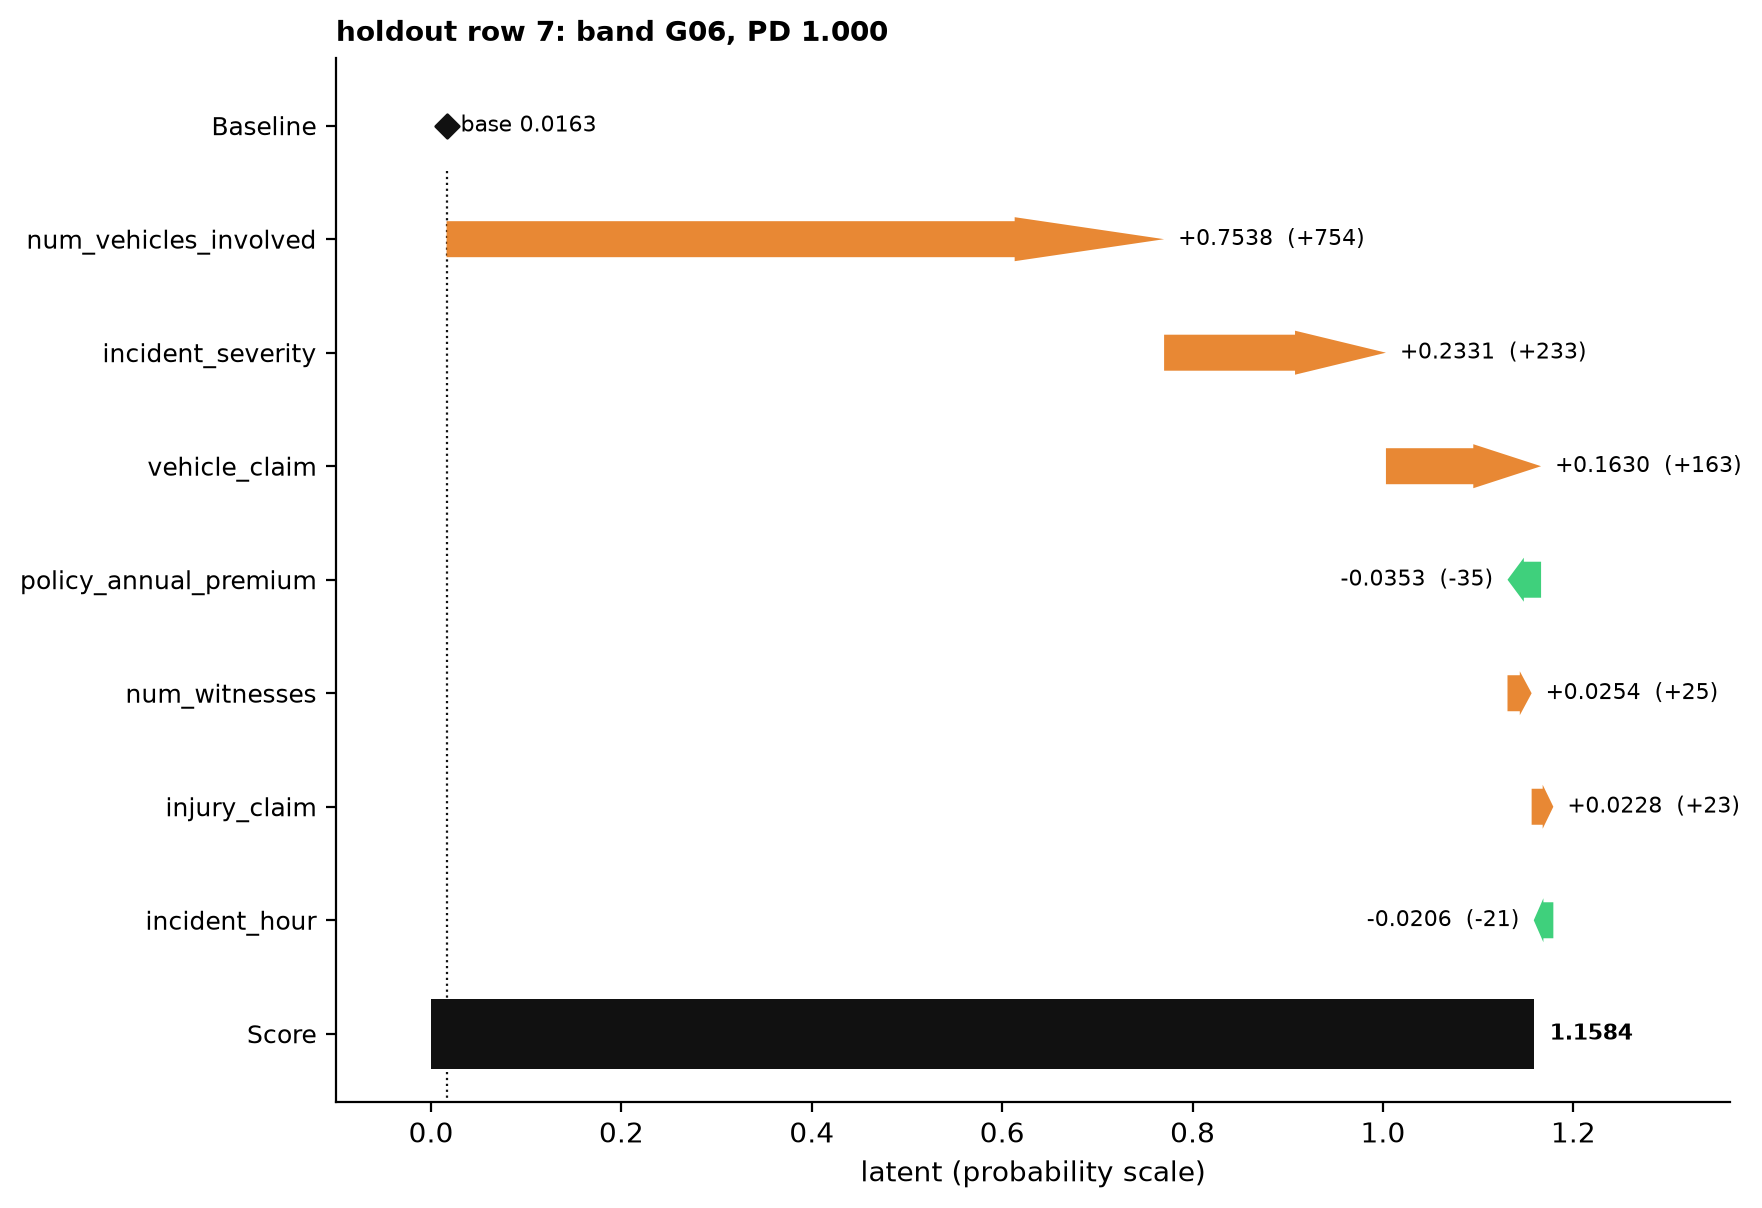

In [15]:
decisions = [
    decide(art, r.tolist(), top_k=3, include_contributions=True)
    for r in X_va.to_numpy()
]
worst = max(range(len(decisions)), key=lambda i: decisions[i]["latent_int"])
fig, ax = waterfall(
    decisions[worst],
    max_features=8,
    title=f"holdout row {worst}: band {decisions[worst]['band']}, PD {decisions[worst]['pd']:.3f}",
)
plt.show()

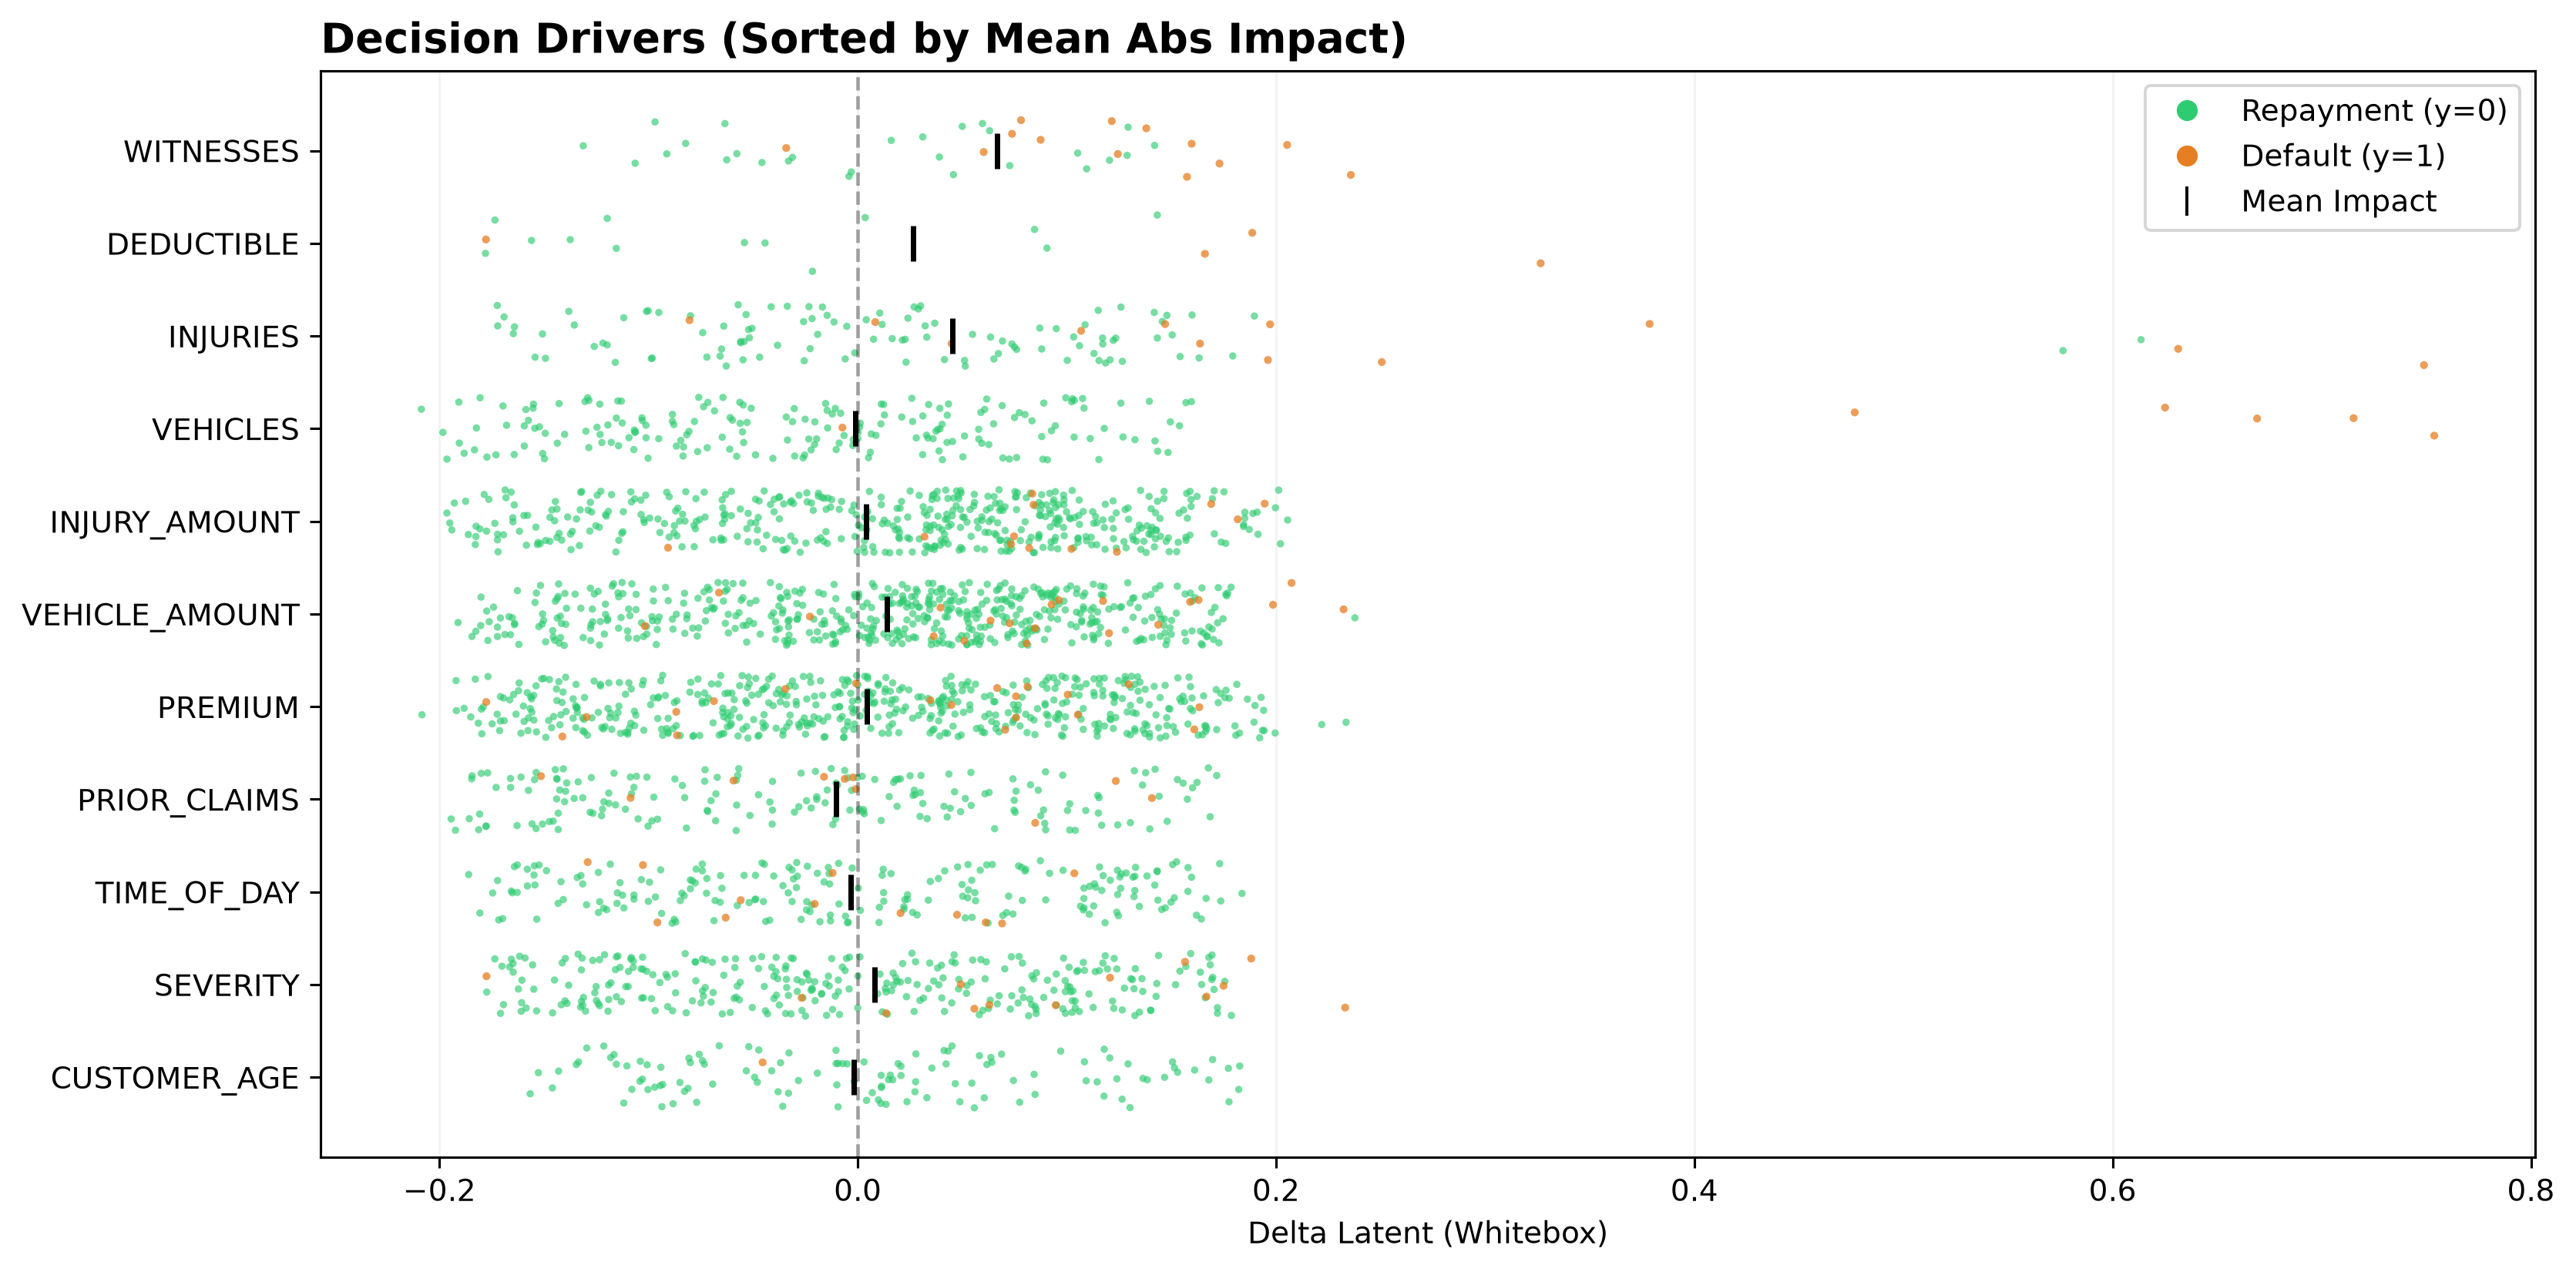

In [16]:
fig, ax = decision_drivers(decisions, y=y_va.to_numpy())
plt.show()

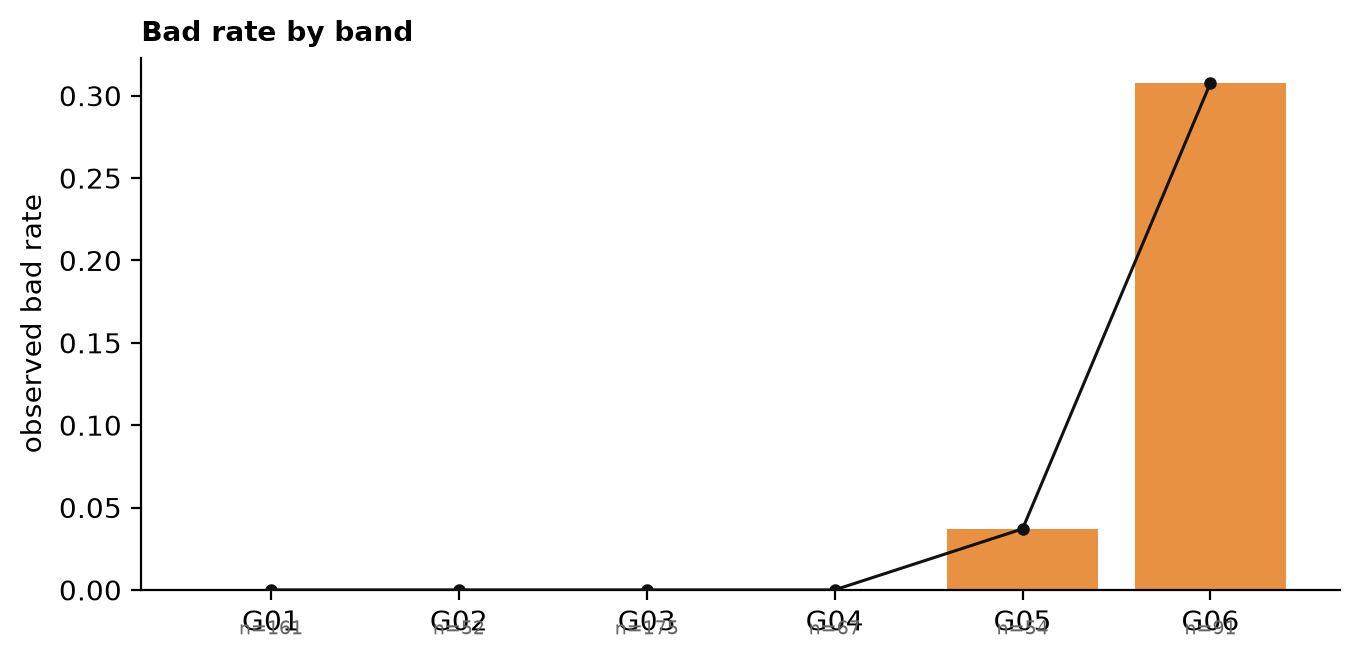

In [17]:
fig, ax = band_ladder(decisions, y_va.to_numpy())
plt.show()

## 10. Side by side with xbooster

Your own package reads the CatBoost trees directly: a leaf-level rule table, WOE/PDO points, and SHAP-based
score decomposition. Same teacher, same holdout, so the two explanation styles can be compared.

In [18]:
from scipy.stats import spearmanr
from xbooster.cb_constructor import CBScorecardConstructor

xb = CBScorecardConstructor(teacher, Pool(X_tr, y_tr))
rules = xb.construct_scorecard()
print("rule table:", rules.shape, "| first tree, full paths:")
display(
    rules.loc[
        rules.Tree == 0,
        ["LeafIndex", "Count", "EventRate", "XAddEvidence", "WOE", "DetailedSplit"],
    ].head(4)
)
shap_pts = xb.predict_score(X_va, method="shap")
dec = xb.predict_scores(X_va, method="shap")
cml_latent = np.array([d["latent_int"] for d in decisions])
print(
    f"holdout Gini  xbooster SHAP points={gini(y_va, -shap_pts):.3f}  compileml latent={gini(y_va, cml_latent):.3f}"
)
print(
    f"Spearman(xbooster SHAP points, compileml latent) = {spearmanr(-shap_pts, cml_latent).correlation:.3f}"
)
xb_top1 = [
    FEATURES[i] for i in dec[[f + "_score" for f in FEATURES]].to_numpy().argmin(axis=1)
]
cml_top1 = [
    d["reasons_negative"][0]["feature"] if d["reasons_negative"] else None
    for d in decisions
]
print(
    f"top-1 risk driver agrees on {np.mean([a == b for a, b in zip(xb_top1, cml_top1)]):.0%} of rows"
)

rule table: (1594, 14) | first tree, full paths:


,LeafIndex,Count,EventRate,XAddEvidence,WOE,DetailedSplit
0,0,55.0,0.381818,-0.024,2.462601,vehicle_claim <= 2940 AND injury_claim <= 1013...
1,1,0.0,0.050000,0.000,0.000000,vehicle_claim <= 2940 AND injury_claim <= 1013...
2,2,76.0,0.039474,-0.153,-0.247408,vehicle_claim <= 2940 AND injury_claim > 10130...
3,3,0.0,0.050000,0.000,0.000000,vehicle_claim <= 2940 AND injury_claim > 10130...


holdout Gini  xbooster SHAP points=0.970  compileml latent=0.956
Spearman(xbooster SHAP points, compileml latent) = 0.819
top-1 risk driver agrees on 63% of rows
